# Experiment Analysis

### Hyperparameter space
|Hyperparameter|Type|Range (Original)|Range(Paper)|
|--|--|--|--|
|n_layers |IntDistribution |[1,4]|[1,4]|
|embedding_dim |CategoricalDistribution |[32, 64, 96, 128]|[32, 64, 96, 128, **256**]|
|lr |FloatDistribution (log) |[1e-5, 1e-1]|[1e-5, 1e-1]|
|lambda_val |FloatDistribution (log) |[1e-6, 1e-1]|[1e-6, 1e-1]|
|batch_size |IntDistribution |[512, 2,048]|[512, **4,096**]|
|optimizer |CategoricalDistribution |[Adam, RMSprop, SGD]|[Adam, RMSprop, SGD]|

### 100K Dataset

| Run | Best | Trials | Epochs | Eval every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>objective | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | |100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last recall | Loose | All models  | First run after correcting loss function |
|1 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last recall | Loose | All models | Running more epochs to get a better model |
|2 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last recall | Loose/Strict | All models | Saw overfitting, but didn't have the metric values |
|3 | |200 | 10,000 | 200 | `eval > 3` | Structural | Yes | None | Last recall | Loose/Strict | - Full graph <br> - Dominant sets | Noticed that by running all 10,000 epocs had lower recall|
|4 | |200 | 4,000 | 50 | `eval > 3` | Structural | Yes | Early | Best recall | Loose/Strict | Full graph  | Added early stoppage and best recall reporting to get better models |
|5 | |200 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best recall | Loose/Strict | Full graph | We should include all reviews, not only the good ones<br>Light GCN is only about interactions. |
|6 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best recall | Loose/Strict | All models | Since last model worked better for Full graph, running for all |
|7 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best recall | Loose/Strict | All models | Trained the random sets based on the best parameters for each the dominant set |

### 1M Dataset

| Run | Best | Trials | Epochs | Eval every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>objective | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | | 100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last recall | Loose | All models  | First run after correcting loss function |
|1 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best recall | Loose/Strict | All models | Using iterations from 100K, results seem more consistent |
 

In [701]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_param_importances
from optuna.importance import get_param_importances
from optuna.trial import TrialState
import seaborn as sns
import datetime

color_map = {'1c1d': '#5CAF50',
             '1c2d': 'skyblue',
             '1c3d': 'salmon',
             'full': 'forestgreen'}

pd.set_option('display.max_columns',None)

exp_name = 'e_100K'
#exp_name = 'e_1M'
version=f'historic_results/{exp_name}/pass_7/'
#root=f'historic_results/{exp_name}/'
#root=''
#version=''

In [702]:
df = pd.read_parquet(f'{version}{exp_name}.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,cycle,early_stopping,ds_users,ds_items,ds_time
2,e_100K_1c1dcs,0.255079,0.069114,0.041393,0.065488,0.255833,0.069904,0.046967,0.068993,3228.672004,8.647057,0.092145,602,8976,65267,9818,9818,50,1,256,0.000647,0.000001,1167,Adam,"[0.6835147142410278, 0.6732559204101562, 0.647...","[0.6308634281158447, 0.6260088086128235, 0.609...","[0.002522473022003513, 0.002481666833656341, 0...","[0.0018032786885245904, 0.0018032786885245904,...","[0.0022901831171204244, 0.0023201647386680646,...",0.071728,1600,True,303.0,232.0,19.501368
3,e_100K_1c1dcs_rand1,0.242574,0.124794,0.052049,0.096206,0.249925,0.128487,0.053770,0.095988,0.000000,7.590814,0.095158,610,8336,65267,9818,9818,50,1,256,0.000647,0.000001,1167,Adam,"[0.6803696155548096, 0.6716706156730652, 0.652...","[0.6297505497932434, 0.6262357234954834, 0.613...","[0.0017570187739939422, 0.003211767210233653, ...","[0.0019672131147540984, 0.002377049180327869, ...","[0.0022650543001071217, 0.002943179938915823, ...",0.128356,1350,True,NaN,NaN,NaN
4,e_100K_1c1dcs_rand2,0.254636,0.117212,0.053033,0.096022,0.252107,0.114912,0.056721,0.098143,0.000000,6.175256,0.095724,610,8332,65267,9818,9818,50,1,256,0.000647,0.000001,1167,Adam,"[0.6820825934410095, 0.6733316779136658, 0.651...","[0.6304731369018555, 0.6263900995254517, 0.611...","[0.0021443290654760954, 0.002584201995996186, ...","[0.0013114754098360656, 0.001639344262295082, ...","[0.0024391898237706563, 0.0027884498072278724,...",0.126454,1000,True,NaN,NaN,NaN
5,e_100K_1c1dcs_rand3,0.253574,0.109711,0.052787,0.091950,0.242697,0.114780,0.051885,0.092749,0.000000,7.279588,0.095209,610,8330,65267,9818,9818,50,1,256,0.000647,0.000001,1167,Adam,"[0.6797037124633789, 0.6745275259017944, 0.653...","[0.6303321719169617, 0.6270853877067566, 0.614...","[0.000817892234521887, 0.001147531524665196, 0...","[0.0012295081967213116, 0.0018032786885245904,...","[0.0011889901481619365, 0.0017612575444473323,...",0.115076,1300,True,NaN,NaN,NaN
6,e_100K_1c1dcs_rand4,0.248781,0.122586,0.055738,0.091622,0.249615,0.134069,0.059426,0.108604,0.000000,6.365306,0.096065,610,8278,65267,9818,9818,50,1,256,0.000647,0.000001,1167,Adam,"[0.68094402551651, 0.6730430126190186, 0.65175...","[0.6298753023147583, 0.6259926557540894, 0.612...","[0.002949672933452659, 0.003101707109631989, 0...","[0.001967213114754099, 0.002377049180327869, 0...","[0.002919536041793136, 0.0034500733644836352, ...",0.127390,1050,True,NaN,NaN,NaN


## Losses for "Strict" DS Runs

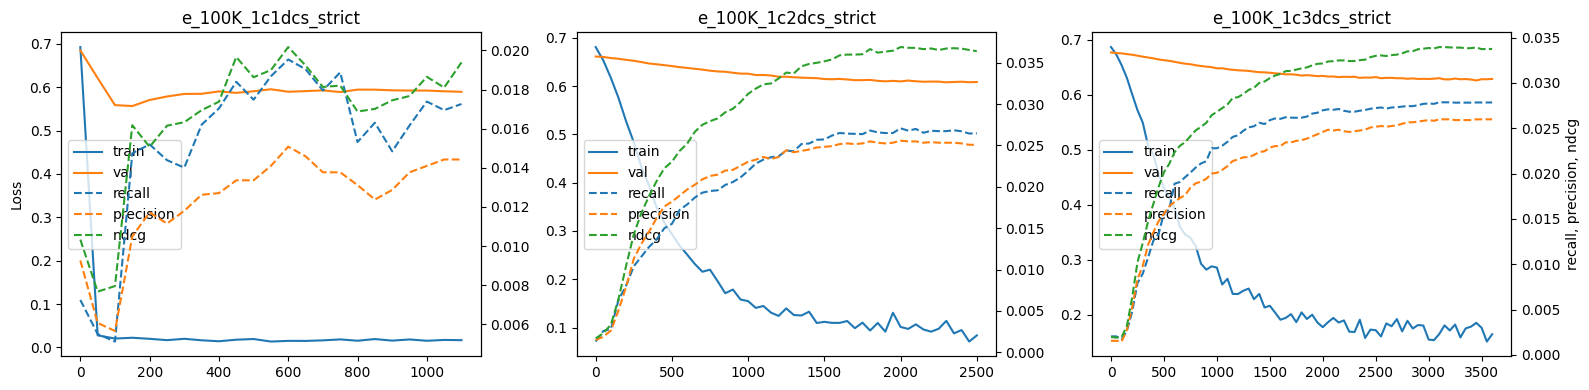

In [703]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
    
    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict.png')
plt.show()


## Losses for non-"Strict" DS and non-Random Runs

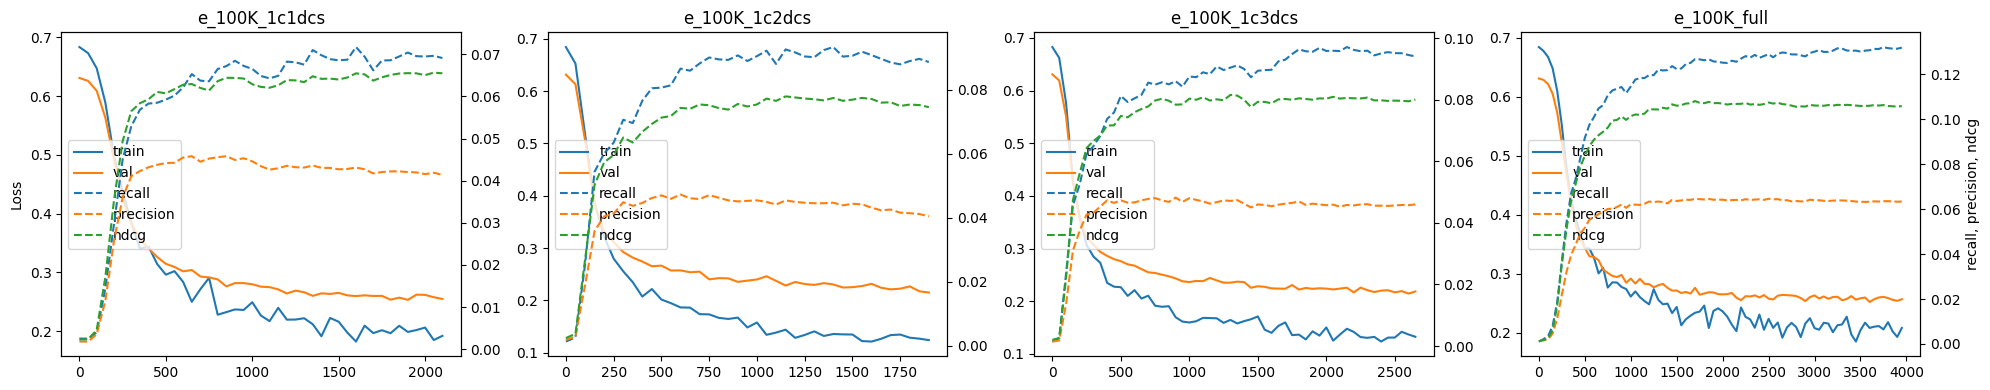

In [704]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose.png')
plt.show()

## Trial analysis

In [705]:
experiments_ran = df[~df['experiment'].str.contains('_rand')]['experiment']

data =  {}
trials = {}
ranges = ''

for exp in experiments_ran:
    study = optuna.load_study(study_name=f'Study_{exp}', storage=f'sqlite:///{version}{exp_name}.sqlite3')
    plot_param_importances(study)

    importance = get_param_importances(study)
    params = {}
    for param, value in importance.items():
        #print(f"{param}: {value}")
        params[param] = value

    ranges = study.get_trials()[0].distributions

    pruned_trials = len(study.get_trials(deepcopy=False, states=[TrialState.PRUNED]))
    complete_trials = len(study.get_trials(deepcopy=False, states=[TrialState.COMPLETE]))

    data[exp] = params
    trials[exp] = {'pruned':pruned_trials, 'complete':complete_trials}

importances_df = pd.DataFrame.from_dict(data, orient='index')
trials_df = pd.DataFrame.from_dict(trials, orient='index')
importances_df

,optimizer,n_layers,batch_size,lr,embedding_dim,lambda_val
e_100K_1c1dcs,0.827661,0.073046,0.046520,0.025656,0.021916,0.005201
e_100K_1c1dcs_strict,0.822278,0.004403,0.032277,0.090049,0.032050,0.018943
e_100K_1c2dcs,0.814933,0.056255,0.040643,0.022869,0.063331,0.001970
e_100K_1c2dcs_strict,0.223757,0.184593,0.336273,0.151157,0.079834,0.024385
e_100K_1c3dcs,0.856316,0.096001,0.028486,0.009271,0.009690,0.000236
e_100K_1c3dcs_strict,0.598882,0.174946,0.042879,0.048998,0.107038,0.027258
e_100K_full,0.795423,0.095542,0.044368,0.019522,0.030637,0.014509


In [706]:
studies = optuna.get_all_study_names(storage=f'sqlite:///{version}{exp_name}.sqlite3')

results = {}
for study_name in studies:
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')
    trials = {}
    for trial in study.get_trials():
        parameters = trial.params
        parameters.update({'status': trial.state})
        parameters.update({'value': trial.value})
        trials[trial.number] = parameters

    results[study_name] = trials

flattened_data = {
    (outer_key, inner_key): values 
    for outer_key, inner_dict in results.items() 
    for inner_key, values in inner_dict.items()
}
flattened_data

trials_params = pd.DataFrame.from_dict(flattened_data, orient='index').reset_index(names=['study','trial'])
trials_params['status'] = trials_params['status'].map({x: TrialState(x).__str__().split('.')[1].lower() for x in range(0,5)})
trials_params.head()


,study,trial,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,status,value
0,Study_e_100K_full,0,3,128,0.000082,0.000054,611,RMSprop,complete,0.034358
1,Study_e_100K_full,1,4,64,0.003667,0.017184,1653,Adam,complete,0.014013
2,Study_e_100K_full,2,2,64,0.003740,0.000006,2424,Adam,complete,0.058289
3,Study_e_100K_full,3,4,96,0.000040,0.002938,836,Adam,complete,0.007687
4,Study_e_100K_full,4,4,256,0.032118,0.000011,1461,Adam,complete,0.020245


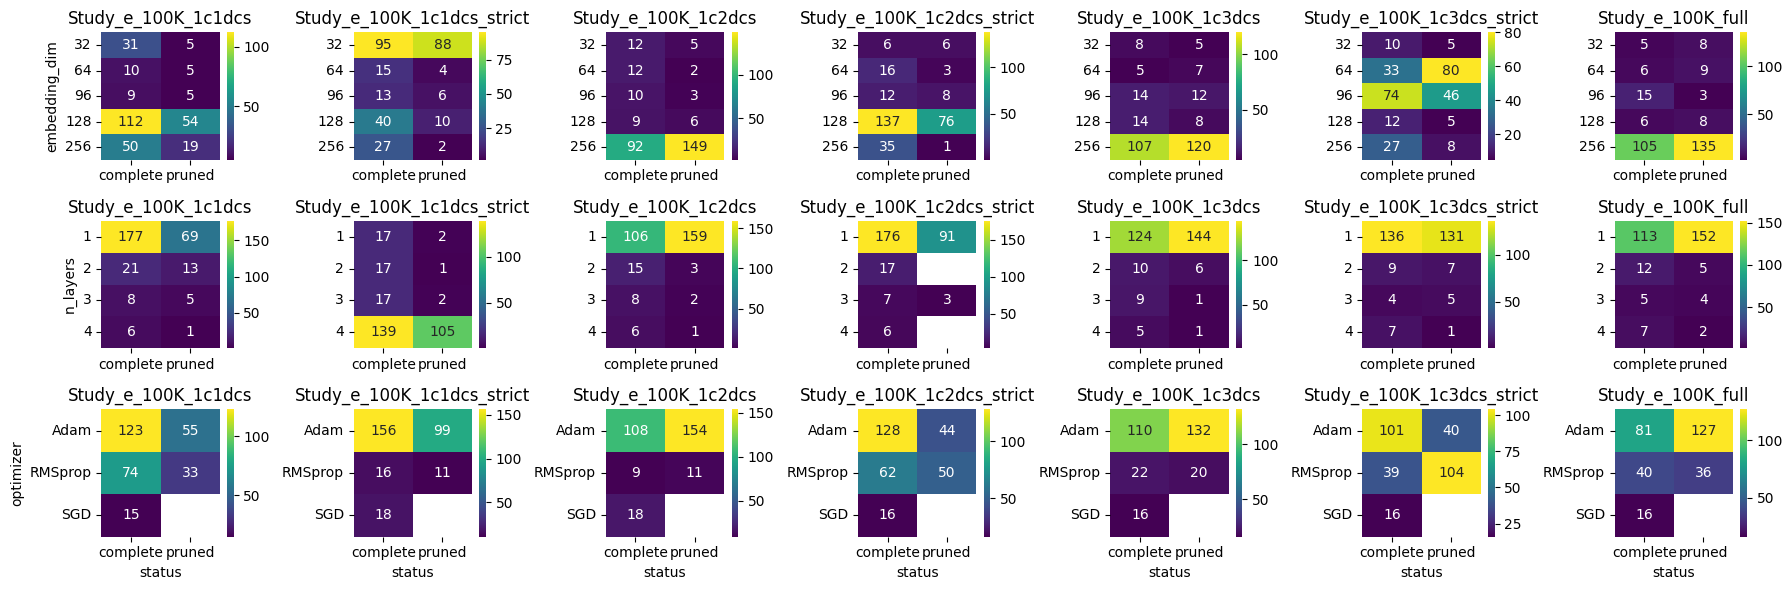

In [707]:
plt.figure(figsize=(18,6))
hyper_params = ['embedding_dim','n_layers','optimizer']

for j,param in enumerate(hyper_params):
    df_t = trials_params.groupby(['study','status',param]).count().reset_index()
    df_t = df_t[~df_t['study'].str.contains('_rand')]

    for i, study in enumerate(df_t['study'].unique()):
        plt.subplot(len(hyper_params),df_t['study'].nunique(),j*(df_t['study'].nunique())+i+1)
        plt.title(study)
        sub_df = df_t[df_t['study']==study]
        ax = sns.heatmap(sub_df.pivot(index=param, columns='status', values='trial'), cmap='viridis', annot=True, fmt='.0f')
        plt.yticks(rotation=0)

        if i != 0:
            ax.set(ylabel=None)
        
        if j != len(hyper_params)-1:
            ax.set(xlabel=None)

plt.tight_layout()
plt.savefig(version+'trials_hyperparmeters.png')
plt.show()

In [708]:
ranges

{'n_layers': IntDistribution(high=4, log=False, low=1, step=1),
 'embedding_dim': CategoricalDistribution(choices=(32, 64, 96, 128, 256)),
 'lr': FloatDistribution(high=0.1, log=True, low=1e-05, step=None),
 'lambda_val': FloatDistribution(high=0.1, log=True, low=1e-06, step=None),
 'batch_size': IntDistribution(high=4096, log=False, low=512, step=1),
 'optimizer': CategoricalDistribution(choices=('Adam', 'RMSprop', 'SGD'))}

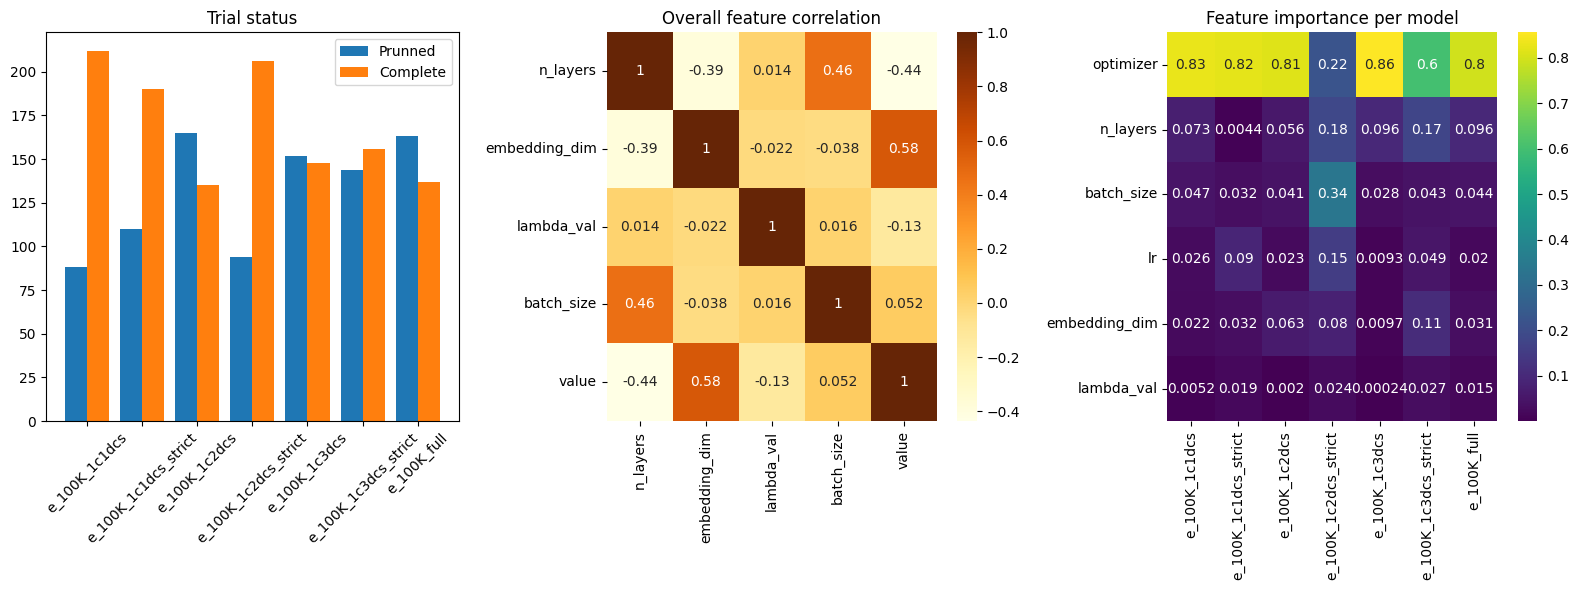

In [709]:
x = np.arange(len(trials_df))
width = 0.4

plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
plt.bar(x = x, width = width, height=trials_df['pruned'], label='Prunned')
plt.bar(x = x+width, width = width, height=trials_df['complete'], label='Complete')

plt.legend()
plt.xticks(x+width/2, trials_df.index, rotation=45)

plt.title('Trial status')

plt.subplot(1,3,2)
sns.heatmap(trials_params[['n_layers','embedding_dim','lambda_val','batch_size','value']].corr(), cmap='YlOrBr', annot=True)
plt.title('Overall feature correlation')

plt.subplot(1,3,3)
sns.heatmap(importances_df.T, annot=True, cmap='viridis')
plt.title('Feature importance per model')

plt.tight_layout()
plt.savefig(version+'trials_feature_importance.png')
plt.show()

## Visualizations

In [710]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
train_features = ['best_recall','cycle','early_stopping'] if "best_recall" in df.columns else []
time_features = ['optim_time','train_time','infer_time'] + (['ds_time'] if "ds_time" in df.columns else [])
edge_features =  ['train_edges','ds_users', 'ds_items']
numerical_features = val_features + test_features + train_features 
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

cleanup_columns = ['ds_time','ds_users','ds_items']
for col in cleanup_columns:
    if col not in df:
        df[col] = np.nan

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
color_dict = { exp:color_map[exp[0:4]] for exp in random_experiments_stats['experiment'].unique()}
random_experiments_stats.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,optim_time,train_time,infer_time,ds_time,train_edges,ds_users,ds_items,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
2,1c1dcs,0.255079,0.069114,0.041393,0.065488,0.255833,0.069904,0.046967,0.068993,0.071728,1600,True,3228.672004,8.647057,0.092145,19.501368,65267,303.0,232.0,1,256,0.000647,0.000001,1167,Adam
3,1c1dcs_rand,0.242574,0.124794,0.052049,0.096206,0.249925,0.128487,0.053770,0.095988,0.128356,1350,True,0.000000,7.590814,0.095158,NaN,65267,NaN,NaN,1,256,0.000647,0.000001,1167,Adam
4,1c1dcs_rand,0.254636,0.117212,0.053033,0.096022,0.252107,0.114912,0.056721,0.098143,0.126454,1000,True,0.000000,6.175256,0.095724,NaN,65267,NaN,NaN,1,256,0.000647,0.000001,1167,Adam
5,1c1dcs_rand,0.253574,0.109711,0.052787,0.091950,0.242697,0.114780,0.051885,0.092749,0.115076,1300,True,0.000000,7.279588,0.095209,NaN,65267,NaN,NaN,1,256,0.000647,0.000001,1167,Adam
6,1c1dcs_rand,0.248781,0.122586,0.055738,0.091622,0.249615,0.134069,0.059426,0.108604,0.127390,1050,True,0.000000,6.365306,0.096065,NaN,65267,NaN,NaN,1,256,0.000647,0.000001,1167,Adam


In [711]:
total_run = random_experiments_stats[time_features].sum().sum()
print('Total run time: ', str(datetime.timedelta(seconds=total_run)))

Total run time:  5:04:25.294103


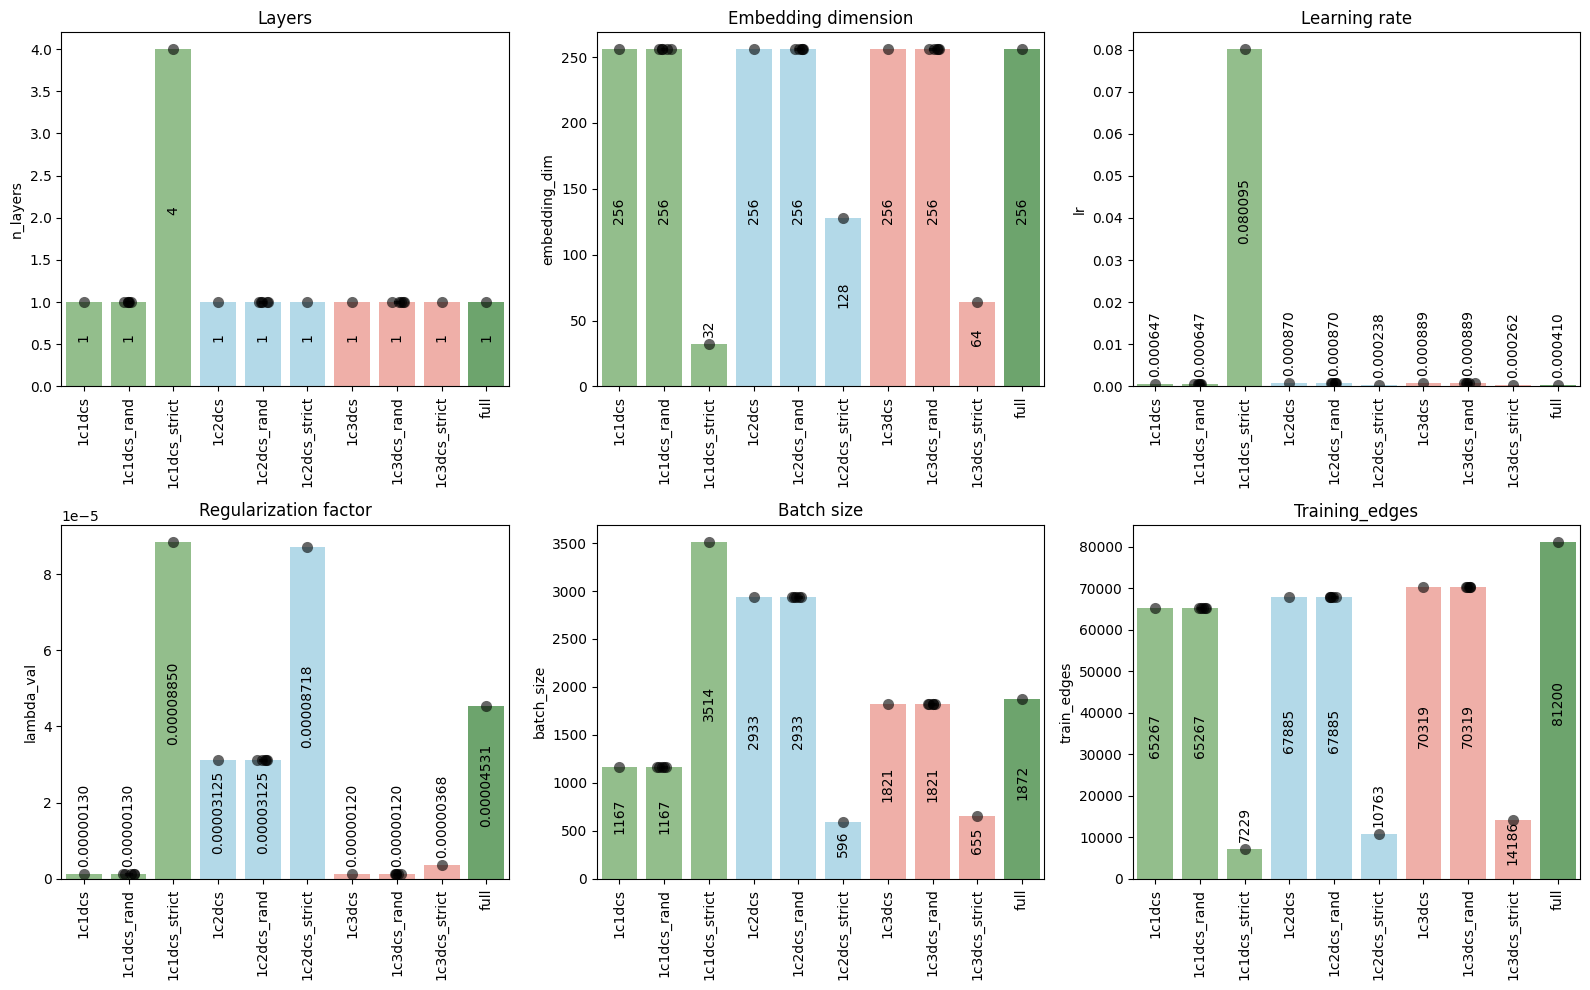

In [712]:

new_df = df.copy()
new_df['experiment'] = new_df['experiment'].apply(lambda x: x[len(exp_name)+1:])

plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

plt.figure(figsize=(16,10))

cols = ['n_layers','embedding_dim','lr','batch_size']

for i,metric in enumerate(plots):
    plt.subplot(n_plots_height,n_plots_wide,i+1)

    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()


In [713]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )


result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result.head()

,experiment,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,best_recall_mean,best_recall_std,cycle_mean,cycle_std,early_stopping_mean,early_stopping_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,ds_time_mean,ds_time_std,train_edges_mean,ds_users_mean,ds_items_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.255079,0.000000,0.069114,0.000000,0.041393,0.000000,0.065488,0.000000,0.255833,0.000000,0.069904,0.000000,0.046967,0.000000,0.068993,0.000000,0.071728,0.000000,1600.0,0.000000,1.0,0.0,3228.672004,0.0,8.647057,0.000000,0.092145,0.000000,19.501368,0.0,65267.0,303.0,232.0,[1],[256],[0.0006471612370182435],[1.2969004803070332e-06],[1167],[Adam]
1,1c1dcs_rand,0.250513,0.004964,0.118806,0.005836,0.053246,0.001439,0.094345,0.002341,0.247529,0.004251,0.122216,0.008659,0.055721,0.002933,0.098424,0.006022,0.123926,0.005450,1200.0,162.018517,1.0,0.0,0.000000,0.0,6.779608,0.618566,0.095609,0.000407,0.000000,0.0,65267.0,0.0,0.0,[1],[256],[0.0006471612370182435],[1.2969004803070332e-06],[1167],[Adam]
2,1c1dcs_strict,0.588803,0.000000,0.017263,0.000000,0.014426,0.000000,0.019391,0.000000,0.591493,0.000000,0.018966,0.000000,0.016148,0.000000,0.022584,0.000000,0.019540,0.000000,600.0,0.000000,1.0,0.0,3004.976222,0.0,3.443227,0.000000,0.081850,0.000000,19.501368,0.0,7229.0,303.0,232.0,[4],[32],[0.08009533750633052],[8.850293322107583e-05],[3514],[Adam]
3,1c2dcs,0.218228,0.000000,0.088730,0.000000,0.040492,0.000000,0.074632,0.000000,0.225329,0.000000,0.094537,0.000000,0.043607,0.000000,0.081383,0.000000,0.093412,0.000000,1400.0,0.000000,1.0,0.0,2549.675555,0.0,7.373242,0.000000,0.096391,0.000000,24.705128,0.0,67885.0,324.0,3679.0,[1],[256],[0.0008698526161511226],[3.1245372325829466e-05],[2933],[Adam]
4,1c2dcs_rand,0.231551,0.004621,0.095112,0.003675,0.044508,0.001054,0.076073,0.003483,0.232156,0.004920,0.092418,0.005861,0.045393,0.002263,0.075095,0.002221,0.113004,0.004042,410.0,96.176920,1.0,0.0,0.000000,0.0,3.741069,0.394369,0.092871,0.001035,0.000000,0.0,67885.0,0.0,0.0,[1],[256],[0.0008698526161511226],[3.1245372325829466e-05],[2933],[Adam]


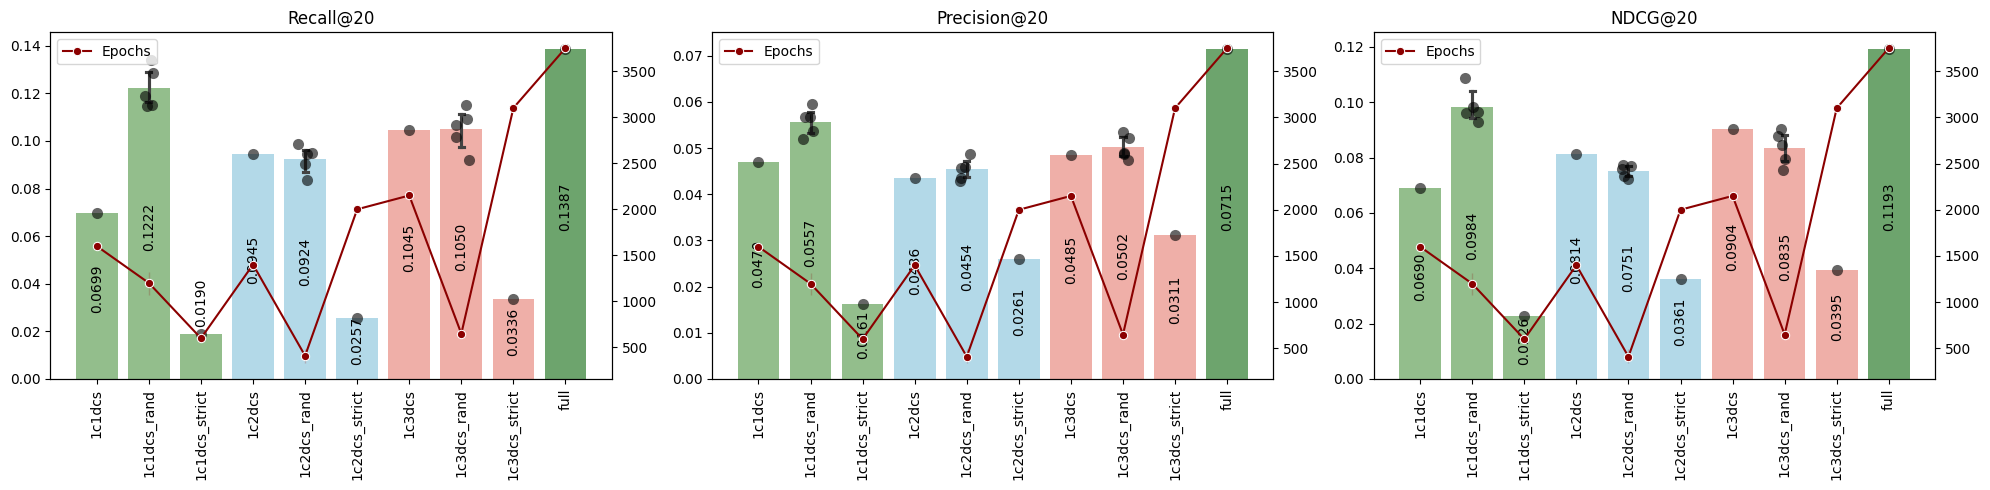

In [714]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']

plt.figure(figsize=(20,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)
    
    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks(rotation=90)

    ax2 = ax.twinx()
    #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
    if 'cycle' in random_experiments_stats.columns:
        sns.lineplot(data=random_experiments_stats, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
        ax2.set_ylabel('Training epochs')

    plt.title(titles[i])
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(version+'experiments_metrics.png')
plt.show()

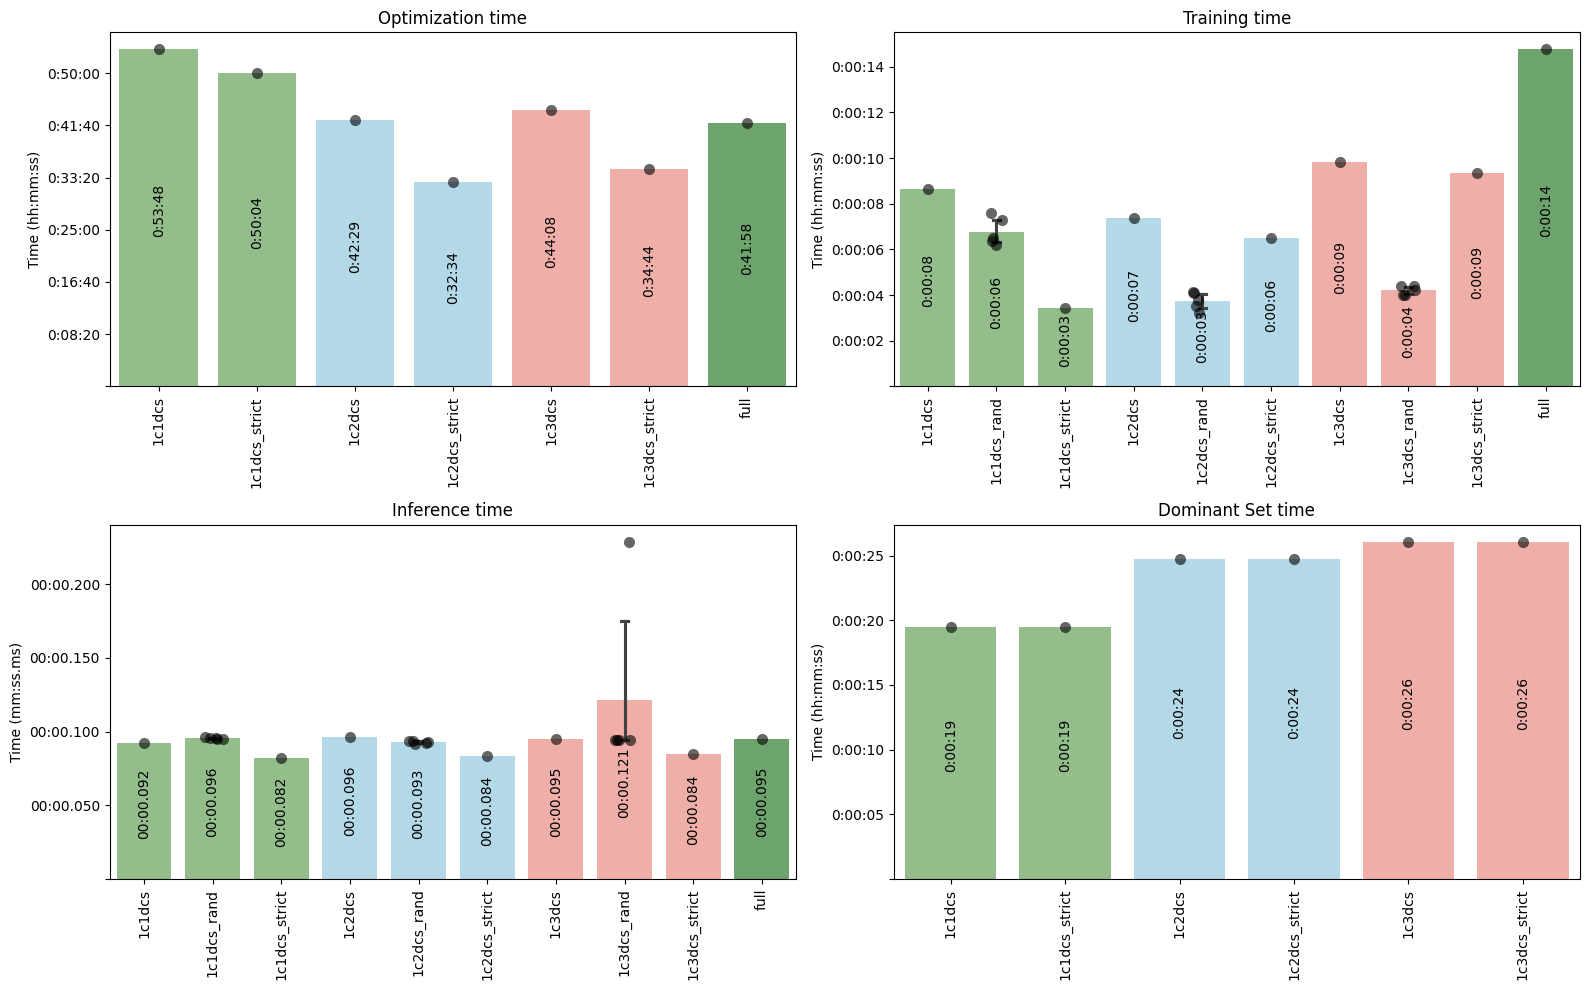

In [715]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for i, metric in enumerate(plots):
    plt.subplot(n_plots_height, n_plots_wide, i+1)

    # Create the barplot
    ax = sns.barplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        errorbar=('ci', 95),
        capsize=0.1, 
        alpha=0.7, 
        palette=color_dict,  
        hue='experiment', 
        legend=False
    ) 

    # --- FIX FOR BAR LABELS ---
    # Iterate through all containers generated by Seaborn's hue
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        # Generate a label list directly from the bar heights in this specific container
        labels = [format_time(val) for val in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    # --------------------------


    # Add the stripplot
    sns.stripplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        color='black', 
        size=8, 
        alpha=0.6, 
        jitter=0.15,
        ax=ax
    )
    
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

    # Use the mean of the actual current metric to decide the axis label
    current_mean = random_experiments_stats[metric].mean()
    if current_mean < 1:
        plt.ylabel('Time (mm:ss.ms)')
    else:
        plt.ylabel('Time (hh:mm:ss)')
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
plt.savefig(version+'experiments_times.png')
plt.show()

In [699]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in result_viewable.columns }
    result_viewable.rename(rename_dict, axis=1, inplace=True)


In [700]:
result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,train_edges,ds_users,ds_items,optim_time,train_time,infer_time,ds_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.1991,0.0817,0.0397,0.0698,0.2026,0.0808,0.0407,0.0701,53441.0,320.0,227.0,01:03:02,00:00:29,00:00:00,00:00:14,[1],[256],[0.00015307634158511117],[2.1353196343566097e-05],[2414],[RMSprop]
1,1c1dcs_strict,0.4481,0.0259,0.0163,0.0249,0.4509,0.0199,0.0168,0.0224,6489.0,320.0,227.0,00:51:55,00:00:31,00:00:00,00:00:14,[4],[256],[0.004550984368885091],[2.5579304554057094e-05],[2480],[RMSprop]
2,1c2dcs,0.2132,0.0668,0.0346,0.0567,0.2282,0.0628,0.0341,0.0529,54738.0,325.0,3332.0,01:10:10,00:00:29,00:00:00,00:00:18,[1],[256],[0.013836294474971499],[0.0004531339956068042],[3476],[RMSprop]
3,1c2dcs_strict,0.5423,0.0109,0.0116,0.0143,0.5566,0.0103,0.0125,0.0143,9193.0,325.0,3332.0,01:27:43,00:00:22,00:00:00,00:00:18,[1],[256],[0.0027816926346878163],[2.8721672822381886e-05],[1407],[Adam]
4,1c3dcs,0.2083,0.1056,0.0426,0.0789,0.2052,0.0937,0.0428,0.0752,56757.0,343.0,4540.0,01:07:11,00:00:24,00:00:00,00:00:20,[1],[256],[0.00022351400280457083],[0.0004336169477086758],[1225],[Adam]
5,1c3dcs_strict,0.5758,0.0361,0.0236,0.0336,0.5738,0.0409,0.0276,0.0439,12764.0,343.0,4540.0,00:54:38,00:00:19,00:00:00,00:00:20,[1],[96],[0.0001158705045876225],[0.00024854533712462317],[609],[RMSprop]
6,full,0.2429,0.0877,0.0416,0.0700,0.2325,0.1058,0.0494,0.0821,65943.0,0.0,0.0,01:23:11,00:00:27,00:00:00,00:00:00,[1],[256],[0.00012374458262572993],[0.0010051274717894586],[2211],[RMSprop]


# Conclusions and actions

## Symptoms
- Model is overfitting, given the train vs. val losses tracking (don't know about the performance metrics, since they haven't been captured.)
- Full graph is converging too fast, but train/val curves are  too far apart, system may have learned "too" quickly

## Suggested actions
- Add tracking for Recall, precision and NDCG (already did after current run.)
- Verify the random sample methods, since it only randomizes using train_test_split from sklearn, but sets may not be fully-connected or even coherent -> Rolando said this before.
    - Nos llevamos aristas siempre que embos nodos esten representados.
- After the right random sample calculate the dominant set from the sample set. --> from here sample random or structure preserving random.
    - The 5 random runs (absolute random), should sample from the random sample ONLY and maybe use a similar algorithm as the full random sample method, 
        - or maybe sample from the main sample with some other variation, limiting the total amount of rows
- Reduce the seach space for certain parameters (embedding_dim, remove the 32 option for instance, layers remove the 4 layers options) --> **Run 300 instances.**
    - Had done this before, but because of th randomization, we may have gotten a bad batch and seems to not converge.


